In [1]:
import numpy as np
import pandas as pd
import re

In [2]:
data=pd.read_csv("IMDB Dataset.csv")

In [3]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
data.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [5]:
data.isnull().any()

review       False
sentiment    False
dtype: bool

In [6]:
data.isnull().sum()

review       0
sentiment    0
dtype: int64

In [7]:
data.duplicated().sum()

418

In [8]:
data.drop_duplicates(inplace = True)

In [9]:
data.columns

Index(['review', 'sentiment'], dtype='object')

In [10]:
data.shape

(49582, 2)

In [11]:
data.describe()

,review,sentiment
count,49582,49582
unique,49582,2
top,One of the other reviewers has mentioned that ...,positive
freq,1,24884


In [12]:
data['sentiment'].value_counts()

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

Text Normalization

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelBinarizer  # Fixed typo
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer  # Fixed typo
from wordcloud import WordCloud, STOPWORDS  # Fixed typo
from nltk.stem import WordNetLemmatizer  # Fixed typo
from nltk.tokenize import word_tokenize, sent_tokenize
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')
nltk.download('vader_lexicon')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\KAUSHIK\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\KAUSHIK\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     C:\Users\KAUSHIK\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\KAUSHIK\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\KAUSHIK\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\KAUSHIK\AppData\Roaming\nltk_data...


True

In [15]:
lemmatizer = WordNetLemmatizer()

In [16]:
data['review'][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [17]:
text = "One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side."

In [18]:
def clean_text(text):
    text = text.lower()
    
    text = re.sub(r'[^a-z\s]', '', text).strip()
    
    text = re.sub(r'\s+', ' ', text)
    
    words = word_tokenize(text)
    
    stop_words = set(stopwords.words('english'))
    filtered_words = [word for word in words if word not in stop_words]
    
    return ' '.join(filtered_words)

In [19]:
chat_words = {
    # Common internet abbreviations
    'AFAIK': 'As Far As I Know',
    'AFK': 'Away From Keyboard',
    'ASAP': 'As Soon As Possible',
    'FYI': 'For Your Information',
    'BRB': 'Be Right Back',
    'TTYL': 'Talk To You Later',
    'IDK': "I Don't Know",
    'GTG': 'Got To Go',
    'TMI': 'Too Much Information',
    'LOL': 'Laugh Out Loud',
    'BTW': 'By The Way',
    'ICYMI': 'In Case You Missed It',
    'FAQ': 'Frequently Asked Question',
    'TGIF': "Thank God It's Friday",
    'IMO': 'In My Opinion',
    'IMHO': 'In My Humble Opinion',
    'TBH': 'To Be Honest',
    'OMG': 'Oh My God',
    'ROFL': 'Rolling On Floor Laughing',
    'LMAO': 'Laughing My Ass Off',
    'SMH': 'Shaking My Head',
    'NVM': 'Never Mind',
    'IDC': "I Don't Care",
    'ILY': 'I Love You',
    'WTH': 'What The Hell',
    'BFF': 'Best Friends Forever',
    'YOLO': 'You Only Live Once',
    'FTW': 'For The Win',
    'FOMO': 'Fear Of Missing Out',
    'BRUH': 'Brother / Dude',
    'LIT': 'Amazing / Exciting',
    'SUS': 'Suspicious',
    'ICY': 'In Case You',
    'JK': 'Just Kidding',
    'FYI': 'For Your Information',
    'RN': 'Right Now',
    'IDC': "I Don't Care",
    'TBA': 'To Be Announced',
    'TBD': 'To Be Determined',
    'OOTD': 'Outfit Of The Day',
    'DM': 'Direct Message',
    'PM': 'Private Message',
    'IMO': 'In My Opinion',
    'IMHO': 'In My Humble Opinion',
    'IKR': 'I Know Right',
    'IDC': "I Don't Care",
    'IYKYK': 'If You Know You Know',
    'NP': 'No Problem',
    'TY': 'Thank You',
    'TYSM': 'Thank You So Much',
    'YW': "You're Welcome",

    # Common contractions
    "aren't": "are not",
    "can't": "cannot",
    "couldn't": "could not",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hasn't": "has not",
    "haven't": "have not",
    "he's": "he is",
    "she's": "she is",
    "it's": "it is",
    "that's": "that is",
    "there's": "there is",
    "they're": "they are",
    "we're": "we are",
    "weren't": "were not",
    "what's": "what is",
    "who's": "who is",
    "won't": "will not",
    "wouldn't": "would not",
    "you're": "you are",
    "you've": "you have",
    "i'm": "i am",
    "i've": "i have",
    "i'll": "i will",
    "isn't": "is not",
    "wasn't": "was not",
    "shouldn't": "should not",
    "mustn't": "must not",
    "let's": "let us",

    # Emotion/Reaction words often in IMDB reviews
    'meh': 'Unimpressed',
    'ugh': 'Disgusted',
    'yay': 'Excited',
    'woah': 'Surprised',
    'hmm': 'Thinking',
    'nah': 'No',
    'yeah': 'Yes',
    'yup': 'Yes',
    'nope': 'No',
    'kinda': 'Kind Of',
    'gonna': 'Going To',
    'wanna': 'Want To',
    'gotta': 'Got To',
    'aint': 'Is Not',
    'tho': 'Though',
    'cuz': 'Because',
    'coz': 'Because',
    'plz': 'Please',
    'thx': 'Thanks',
    'u': 'You',
    'ur': 'Your',
    'r': 'Are',
    'btw': 'By The Way',
    'bcoz': 'Because',
    'luv': 'Love',
    'gr8': 'Great',
    'b4': 'Before',
    '2day': 'Today',
    '2moro': 'Tomorrow',
    '4u': 'For You',
    'bday': 'Birthday',
    'fam': 'Family',
    'bf': 'Boyfriend',
    'gf': 'Girlfriend',
    'wtv': 'Whatever',
    'ikr': 'I Know Right',
    'idc': "I Don't Care"
}

In [20]:
def chat_conv(text):
  new_text = []
  for w in text.split():
    if w.upper() in chat_words:
      new_text.append(chat_words[w.upper()])
    else:
      new_text.append(w)
  return " ".join(new_text)

In [21]:
data['review'] = data['review'].apply(clean_text)

In [22]:
data['review'] = data['review'].apply(chat_conv)

In [23]:
data['review'][7]

'show amazing fresh innovative idea first aired first years brilliant things dropped show really funny anymore continued decline complete waste time todaybr br truly disgraceful far show fallen writing painfully bad performances almost bad mildly entertaining respite guesthosts show probably wouldnt still air find hard believe creator handselected original cast also chose band hacks followed one recognize brilliance see fit replace mediocrity felt must give stars respect original cast made show huge success show awful cant believe still air'

In [24]:
all_text = " ".join(data['review'])

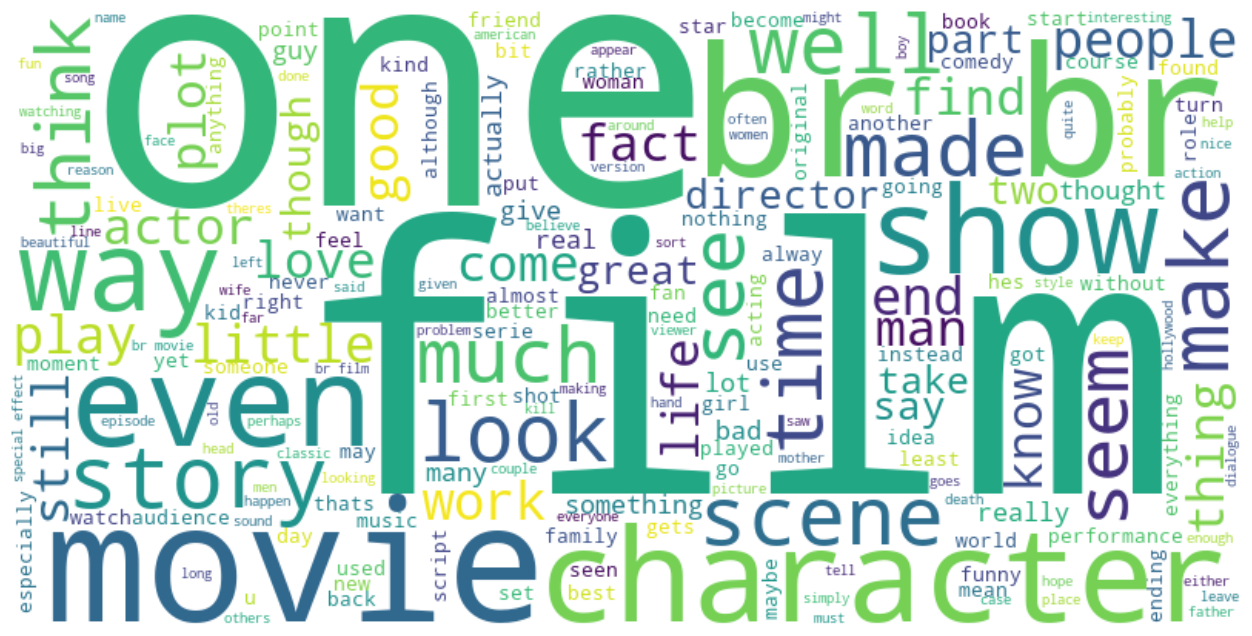

In [25]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [26]:
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(data["review"])

In [27]:
lb = LabelBinarizer()
y = lb.fit_transform(data["sentiment"])

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [70]:
model = LogisticRegression()
model.fit(X_train, y_train)

C:\Users\KAUSHIK\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [72]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8919027931834224
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      4939
           1       0.88      0.91      0.89      4978

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917

[[4316  623]
 [ 449 4529]]


In [74]:
new_text = ["i don't like this movie."]
new_text_cleaned = [clean_text(text) for text in new_text]  # apply same cleaning
new_text_tfidf = tfidf.transform(new_text_cleaned)
prediction = model.predict(new_text_tfidf)
print("Prediction:", lb.inverse_transform(prediction))  # converts back to original label


Prediction: ['negative']


In [76]:
import joblib

In [78]:
joblib.dump(model, 'text_model.pkl')

['text_model.pkl']

In [80]:
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

In [82]:
joblib.dump(lb, 'LabelBinarizer.pkl')

['LabelBinarizer.pkl']